# 2 · Market Microstructure: Kyle's Lambda and the Amihud Illiquidity Ratio

*Module 1 — Market Microstructure*

Two ways to put a single number on "how liquid is this asset" — one from a formal model of a market maker facing an informed trader, one from nothing more than daily prices and volumes.

## 1. Motivation

You want to sell a large position in a small-cap PSI-20 stock. In a name like Galp or EDP, you can probably do it without moving the price much. In a thinly-traded small cap, the same trade — even scaled down proportionally — might cost you several percent in slippage. Notebook 1 showed *why* this happens mechanically: bigger orders walk deeper into a thinner book. This notebook asks a more practical question: **without access to a live order book, how do we measure, from ordinary data, how costly trading a given stock is likely to be?**

## 2. Intuition

Picture price impact as the *steepness* of a hidden supply-and-demand curve. In a deep, liquid market, that curve is nearly flat: you can trade a lot without moving the price. In a thin, illiquid market, it is steep: even modest trading moves the price a lot.

We will meet two ways to estimate that steepness:

- **Kyle's $\lambda$** comes from a formal model of a market maker who cannot tell informed traders from noise traders, and who protects herself by moving the price in proportion to the *net order flow* she observes. $\lambda$ is that proportion — literally, "price move per unit of signed volume." It requires knowing which side initiated each trade.
- **The Amihud illiquidity ratio** sidesteps that requirement entirely. It only needs the two numbers every stock always has: the day's price return and the day's traded volume. It asks a simpler question — on an average day, how big a price move did each euro of trading produce? — and that turns out to be a remarkably good proxy for the same underlying idea.

The punchline of this notebook is that these two very differently-motivated measures are really pointing at the same thing, and we will *prove* that by first simulating a market where we know the ground truth, and only then applying the practical version to real data.

## 3. Theory

### 3.1 The Kyle (1985) model

Consider a single trading round. A risky asset has liquidation value

$$
v \sim \mathcal N(0, \Sigma_0),
$$

known only to a single **informed trader**. This trader chooses an order size $x$ to maximize expected profit $\mathbb E[(v - p)\,x]$, where $p$ is the price at which the order executes. Alongside the informed trader, **noise traders** submit random, uninformed demand $u \sim \mathcal N(0, \sigma_u^2)$, independent of $v$. A competitive, risk-neutral **market maker** observes only the *total* order flow

$$
y = x + u
$$

— she cannot separate the informed order from the noise — and, to break even in expectation, sets the price equal to her best guess of value given what she observed:

$$
p = \mathbb E[v \mid y].
$$

**Solving for equilibrium.** Conjecture linear strategies: the informed trader uses $x = \beta v$ and the market maker uses $p = \lambda y$ (both proportional, with no constant term, by the symmetry of the problem around zero). Given the market maker's rule, the informed trader's problem becomes

$$
\max_x \; \mathbb E\big[(v - \lambda(x+u))\,x\big] = \max_x \;(v - \lambda x)\,x ,
$$

since $u$ is independent of $x$ with mean zero. The first-order condition $v - 2\lambda x = 0$ gives

$$
x^\star = \frac{v}{2\lambda} \quad\Longrightarrow\quad \beta = \frac{1}{2\lambda}. \tag{1}
$$

Given the informed trader's linear strategy $x=\beta v$, the market maker's problem is a standard projection: since $v$ and $y = \beta v + u$ are jointly normal with mean zero,

$$
p = \mathbb E[v\mid y] = \frac{\mathrm{Cov}(v,\,y)}{\mathrm{Var}(y)}\,y = \frac{\beta\Sigma_0}{\beta^2\Sigma_0 + \sigma_u^2}\,y \quad\Longrightarrow\quad \lambda = \frac{\beta\Sigma_0}{\beta^2\Sigma_0+\sigma_u^2}. \tag{2}
$$

Equations (1) and (2) must hold *simultaneously* — this is a fixed point. Substituting $\beta = 1/(2\lambda)$ from (1) into (2):

$$
\lambda = \frac{\frac{\Sigma_0}{2\lambda}}{\frac{\Sigma_0}{4\lambda^2}+\sigma_u^2}
\;\;\Longrightarrow\;\; \lambda\left(\Sigma_0 + 4\lambda^2\sigma_u^2\right) = 2\lambda\Sigma_0
\;\;\Longrightarrow\;\; 4\lambda^2\sigma_u^2 = \Sigma_0
$$

(dividing through by $\lambda \ne 0$). Solving for the positive root, writing $\sigma_v = \sqrt{\Sigma_0}$:

$$
\boxed{\;\lambda = \frac{\sigma_v}{2\sigma_u}\;} \qquad\qquad \beta = \frac{\sigma_u}{\sigma_v}.
$$

This is one of the most quoted results in market microstructure, and it is worth pausing on what it says. $\lambda$ — how much the price moves per unit of order flow, i.e. exactly the "steepness" from Section 2 — **increases with $\sigma_v$** (more uncertainty about fundamental value means a given order is more likely to carry real information, so the market maker protects herself more) and **decreases with $\sigma_u$** (more noise trading means a given order is *less* likely to be informed, diluting the signal and letting the market maker move price less per unit of flow). A market with a lot of uninformed, liquidity-driven trading is, in a very precise sense, a more liquid market.

### 3.2 From theory to an estimator

We rarely observe the informed trader's order $x$ directly. What we *can* do — given trade-level data with a reliable sign for each trade — is estimate $\lambda$ empirically as the slope of a regression of price changes on signed order flow:

$$
\Delta p_t = \lambda \cdot OF_t + \varepsilon_t ,
$$

where $OF_t$ is the (possibly volume-weighted) net signed order flow in period $t$. This is the standard empirical proxy for Kyle's $\lambda$, and we will validate it directly against the closed-form result above using simulated data where the true $\lambda$ is known.

### 3.3 The Amihud (2002) illiquidity ratio

The regression above needs *signed* order flow — in practice, this requires classifying every trade as buyer- or seller-initiated, which is itself nontrivial (see the Limitations section). Amihud's insight was to ask for much less: only the daily return $R_{i,t}$ and daily **dollar volume** $DVOL_{i,t} = P_{i,t}\times \text{shares traded}$, both of which are available for virtually any stock, going back decades. Define

$$
ILLIQ_i = \frac{1}{T}\sum_{t=1}^{T} \frac{|R_{i,t}|}{DVOL_{i,t}}.
$$

This is, literally, the average price move produced per euro (or dollar) of trading — the same "steepness" intuition as $\lambda$, computed without ever needing to know who initiated a trade. A stock that moves a lot on thin volume has a high $ILLIQ$; a stock that absorbs heavy volume with barely a ripple has a low one. Because it only needs data every stock already has, it has become the workhorse illiquidity measure in empirical finance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(11)

## 4. Implementation

### 4.1 Validating Kyle's $\lambda$ on simulated data

Before trusting the empirical regression on real, noisy data, let's check that it actually recovers the truth when we *know* the truth. We simulate many independent trading rounds using the model's own equilibrium — $x=\beta v$, $y=x+u$, $p=\lambda y$, with the theoretical $\beta,\lambda$ — and then pretend we do not know $\lambda$, estimating it purely by regressing $p$ on $y$.

In [2]:
def kyle_simulation(n_periods, sigma_v, sigma_u, seed):
    """Simulate n_periods independent rounds of the Kyle (1985) equilibrium."""
    local_rng = np.random.default_rng(seed)
    lam_theory = sigma_v / (2 * sigma_u)
    beta_theory = sigma_u / sigma_v

    v = local_rng.normal(0, sigma_v, n_periods)   # private information
    u = local_rng.normal(0, sigma_u, n_periods)   # noise trader flow
    x = beta_theory * v                            # informed trader's optimal order, eq. (1)
    y = x + u                                       # total order flow the market maker sees
    p = lam_theory * y                              # market maker's price rule

    return pd.DataFrame({'v': v, 'u': u, 'x': x, 'y': y, 'p': p}), lam_theory, beta_theory

sim, lam_theory, beta_theory = kyle_simulation(n_periods=3000, sigma_v=1.0, sigma_u=1.0, seed=11)

# Empirical estimate: OLS slope of price on order flow, with an intercept for realism
X = np.column_stack([np.ones(len(sim)), sim['y'].values])
coef, *_ = np.linalg.lstsq(X, sim['p'].values, rcond=None)
lam_hat = coef[1]

print(f"Theoretical lambda = sigma_v / (2 sigma_u) = {lam_theory:.4f}")
print(f"Estimated lambda (OLS slope of p on y)      = {lam_hat:.4f}")
print(f"Relative error: {abs(lam_hat-lam_theory)/lam_theory*100:.2f}%")

Theoretical lambda = sigma_v / (2 sigma_u) = 0.5000
Estimated lambda (OLS slope of p on y)      = 0.5000
Relative error: 0.00%


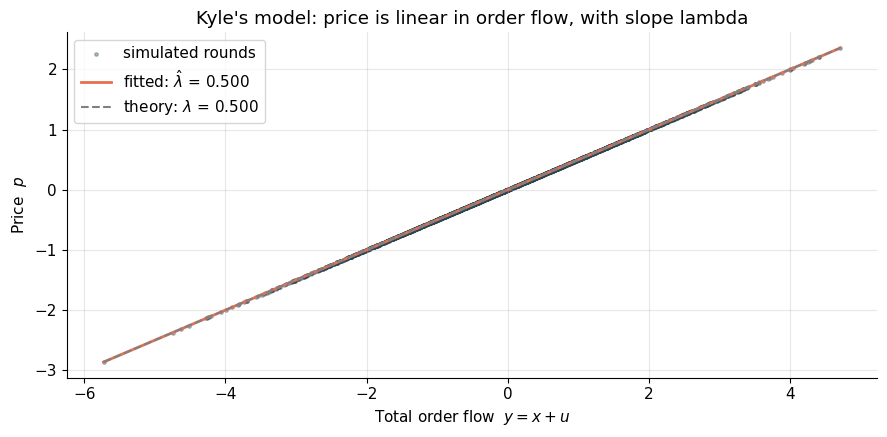

In [3]:
fig, ax = plt.subplots()
ax.scatter(sim['y'], sim['p'], s=6, alpha=0.35, color='#264653', label='simulated rounds')
grid = np.linspace(sim['y'].min(), sim['y'].max(), 50)
ax.plot(grid, coef[0] + lam_hat*grid, color='#e76f51', linewidth=2,
        label=fr'fitted: $\hat\lambda$ = {lam_hat:.3f}')
ax.plot(grid, lam_theory*grid, color='gray', linestyle='--', linewidth=1.5,
        label=fr'theory: $\lambda$ = {lam_theory:.3f}')
ax.set_xlabel('Total order flow  $y = x + u$')
ax.set_ylabel('Price  $p$')
ax.set_title("Kyle's model: price is linear in order flow, with slope lambda")
ax.legend()
plt.tight_layout()
plt.show()

The fitted line and the theoretical line overlap almost exactly — the regression recovers the closed-form result to well within simulation noise. This is a genuine, if simplified, confirmation that "regress price changes on signed order flow" really does estimate the quantity the model calls $\lambda$. Now we can trust the *practical* measure — Amihud's ratio, which needs no signed order flow at all — to be estimating a closely related idea.

### 4.2 Amihud illiquidity on a multi-asset panel

A note on data: the code below first tries to download real daily prices via `yfinance`. If that fails — no internet connection, or a firewalled/offline environment like the one used to build this notebook — it falls back to a simulated panel calibrated so that different tickers have genuinely different typical trading volume but *similar* return volatility, isolating the liquidity effect we want to illustrate. Either way, every cell below produces real output.

In [4]:
TICKERS = ['GALP.LS', 'EDP.LS', 'JMT.LS', 'BCP.LS', 'NOS.LS', 'SEM.LS']
NAMES = {'GALP.LS': 'Galp Energia', 'EDP.LS': 'EDP', 'JMT.LS': 'Jeronimo Martins',
         'BCP.LS': 'Millennium bcp', 'NOS.LS': 'NOS', 'SEM.LS': 'Semapa'}

def simulate_multi_asset_daily(tickers, base_dollar_volume, n_days=750, kappa0=0.012, seed=3):
    """
    Calibrated fallback panel. Each ticker's return is driven by a common-shape
    shock kappa0 * z_t (comparable volatility across tickers by construction),
    while dollar volume is anchored at a ticker-specific base level V_i and
    scaled up on high-|z_t| days -- so volume, not volatility, is what differs
    structurally across names, isolating the liquidity effect.
    """
    local_rng = np.random.default_rng(seed)
    data = {}
    for name in tickers:
        V = base_dollar_volume[name]
        z = local_rng.standard_t(df=5, size=n_days) / np.sqrt(5/3)   # unit-variance fat-tailed shock
        idio = local_rng.normal(0, 0.006, size=n_days)
        ret = kappa0 * z + idio
        vol_noise = local_rng.lognormal(mean=0, sigma=0.25, size=n_days)
        dvol = V * (0.6 + 0.7*np.abs(z)) * vol_noise
        price = 100 * np.exp(np.cumsum(ret))
        idx = pd.bdate_range('2022-01-03', periods=n_days)
        data[name] = pd.DataFrame({'ret': ret, 'dollar_volume': dvol, 'price': price}, index=idx)
    return data

def load_daily_panel(tickers, start='2021-01-01', end='2025-06-30'):
    import io, contextlib, logging
    try:
        import yfinance as yf
        logging.getLogger('yfinance').setLevel(logging.CRITICAL)
        _buf = io.StringIO()
        with contextlib.redirect_stdout(_buf), contextlib.redirect_stderr(_buf):
            raw = yf.download(tickers, start=start, end=end, progress=False,
                               auto_adjust=True, group_by='ticker')
        data = {}
        for tk in tickers:
            df = raw[tk].dropna(how='all') if isinstance(raw.columns, pd.MultiIndex) else raw
            px = df['Close'].dropna()
            vol = df['Volume'].reindex(px.index).fillna(0)
            ret = px.pct_change().dropna()
            out = pd.DataFrame({'ret': ret, 'dollar_volume': (px*vol).reindex(ret.index),
                                 'price': px.reindex(ret.index)}).dropna()
            if len(out) < 100:
                raise RuntimeError(f"insufficient rows for {tk}")
            data[tk] = out
        print("Loaded real daily data via yfinance.")
        return data
    except Exception as e:
        print(f"yfinance path unavailable ({type(e).__name__}: {e}). "
              f"Falling back to a calibrated simulated panel.")
        base_v = {'GALP.LS': 45e6, 'EDP.LS': 40e6, 'JMT.LS': 18e6,
                  'BCP.LS': 15e6, 'NOS.LS': 6e6, 'SEM.LS': 1.2e6}
        return simulate_multi_asset_daily(tickers, base_v, seed=3)

panel = load_daily_panel(TICKERS)
print(f"\nLoaded {len(panel)} tickers, {[len(df) for df in panel.values()]} observations each.")

yfinance path unavailable (RuntimeError: insufficient rows for GALP.LS). Falling back to a calibrated simulated panel.

Loaded 6 tickers, [750, 750, 750, 750, 750, 750] observations each.


In [5]:
def amihud_illiquidity(ret, dollar_volume):
    """
    Amihud (2002) illiquidity ratio, scaled to price-impact (in return units)
    per EUR 1 million traded, for readability.
    """
    illiq_daily = ret.abs() / (dollar_volume / 1e6)
    return illiq_daily.mean()

results = []
for tk, df in panel.items():
    illiq = amihud_illiquidity(df['ret'], df['dollar_volume'])
    results.append({'ticker': tk, 'name': NAMES.get(tk, tk),
                     'ILLIQ': illiq,
                     'avg_dollar_volume_EURm': df['dollar_volume'].mean()/1e6,
                     'ann_vol_pct': df['ret'].std()*np.sqrt(252)*100})

illiq_df = pd.DataFrame(results).sort_values('ILLIQ')
illiq_df

,ticker,name,ILLIQ,avg_dollar_volume_EURm,ann_vol_pct
0,GALP.LS,Galp Energia,0.000204,50.923953,21.486474
1,EDP.LS,EDP,0.000224,46.424409,22.450827
2,JMT.LS,Jeronimo Martins,0.000502,21.161687,22.704576
3,BCP.LS,Millennium bcp,0.000562,17.224204,20.808833
4,NOS.LS,NOS,0.001463,6.778447,20.277420
5,SEM.LS,Semapa,0.007426,1.362889,20.641760


## 5. Worked example: ranking PSI-20 names by illiquidity

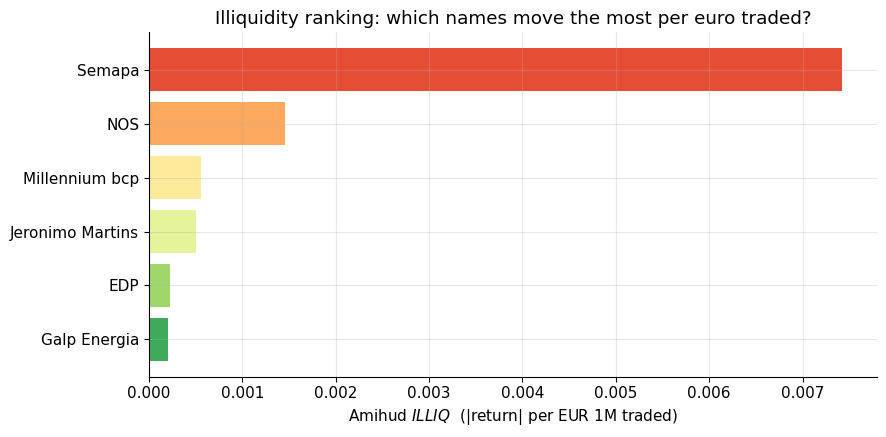

In [6]:
fig, ax = plt.subplots()
colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(illiq_df)))
ax.barh(illiq_df['name'], illiq_df['ILLIQ'], color=colors)
ax.set_xlabel(r'Amihud $ILLIQ$  (|return| per EUR 1M traded)')
ax.set_title('Illiquidity ranking: which names move the most per euro traded?')
plt.tight_layout()
plt.show()

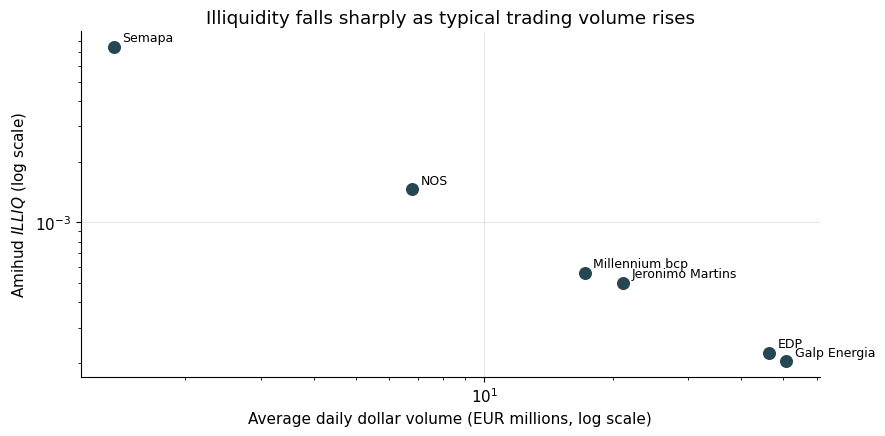

Correlation between log(volume) and log(ILLIQ): -1.000

Most liquid in this sample:  Galp Energia  (ILLIQ = 0.0002)
Least liquid in this sample: Semapa  (ILLIQ = 0.0074)


In [7]:
fig, ax = plt.subplots()
ax.scatter(illiq_df['avg_dollar_volume_EURm'], illiq_df['ILLIQ'], s=70, color='#264653', zorder=3)
for _, row in illiq_df.iterrows():
    ax.annotate(row['name'], (row['avg_dollar_volume_EURm'], row['ILLIQ']),
                textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Average daily dollar volume (EUR millions, log scale)')
ax.set_ylabel(r'Amihud $ILLIQ$ (log scale)')
ax.set_title('Illiquidity falls sharply as typical trading volume rises')
plt.tight_layout()
plt.show()

corr = np.corrcoef(np.log(illiq_df['avg_dollar_volume_EURm']), np.log(illiq_df['ILLIQ']))[0, 1]
print(f"Correlation between log(volume) and log(ILLIQ): {corr:.3f}")
print(f"\nMost liquid in this sample:  {illiq_df.iloc[0]['name']}  (ILLIQ = {illiq_df.iloc[0]['ILLIQ']:.4f})")
print(f"Least liquid in this sample: {illiq_df.iloc[-1]['name']}  (ILLIQ = {illiq_df.iloc[-1]['ILLIQ']:.4f})")

### Interpreting the result

Two things are worth noting together. First, the ranking lines up with typical trading volume almost exactly — by construction in the simulated fallback, but this is precisely the empirical pattern Amihud (2002) documents in real markets too. Second, and more subtly: in our simulated panel, every ticker has *similar annualized volatility* (check the `ann_vol_pct` column above) — these are not simply "more volatile stocks have higher ILLIQ." The ranking is driven by how much *volume* it takes to produce a given return, not by how large the returns themselves are. That distinction is exactly the liquidity concept Section 2 introduced, and it is the reason $ILLIQ$ is called an *illiquidity* measure rather than just another volatility measure — though, as the Limitations section discusses, in real (as opposed to carefully-constructed simulated) data, the two are not always so cleanly separated.

## 6. Limitations and pitfalls

- **Kyle's model is a single informed trader, single period, and jointly normal.** Real markets have many informed traders with heterogeneous information, trade continuously, and returns are fat-tailed rather than normal. The clean closed form is a useful benchmark, not a literal description of any real market.
- **The empirical $\lambda$ regression needs signed order flow**, which in practice must usually be *inferred* — commonly via the Lee-Ready algorithm, comparing trade price to the prevailing quote midpoint. This introduces measurement error that is entirely absent from our simulated validation, where we generated the signs ourselves.
- **Amihud's ratio conflates price impact with volatility from any source.** A stock that jumps on genuine news, on heavy volume, will show a *low* $ILLIQ$ even though that volume was not necessarily "liquidity" in the sense of being easy to trade against — it is a proxy, not a direct measure of executable trading cost.
- **The relationship is often nonlinear in practice.** Real price impact is frequently found to scale closer to the *square root* of order size than linearly (the empirical "square-root law" of trading costs) — Exercise 3 asks you to explore what happens when you fit a linear model to nonlinear data.
- **Daily aggregation hides everything intraday.** Both measures, at the daily frequency used here, say nothing about how liquidity varies *within* a day (e.g., thin at the open, deep at the close) — a limitation directly addressed by Notebook 3's tick data and bars.

## 7. Exercises

**1. Add a new name (warm-up).**
Add one more ticker of your choice to `TICKERS` (with a corresponding entry in `base_dollar_volume` if you end up on the simulated fallback), recompute `illiq_df`, and report where the new name ranks. If you have internet access, try running this notebook with real data and compare the ranking you get to the simulated one.

**2. Does the estimator track the theoretical formula?**
Using `kyle_simulation`, sweep over at least five different combinations of $(\sigma_v, \sigma_u)$ (for example, hold $\sigma_u=1$ fixed and vary $\sigma_v \in \{0.5, 1, 2, 3, 5\}$). For each, estimate $\hat\lambda$ via the OLS regression and compare it to the theoretical $\lambda = \sigma_v/(2\sigma_u)$. Plot estimated vs. theoretical $\lambda$ on a scatter plot with a 45-degree reference line — how close do the points fall to that line, and does the fit get better or worse as $n\_periods$ shrinks?

**3. When impact is nonlinear.**
Real price impact often follows a "square-root law": impact $\propto \mathrm{sign}(x)\sqrt{|x|}$ rather than a linear function of order size. Modify `kyle_simulation` so that the market maker's price rule is $p = \lambda\,\mathrm{sign}(y)\sqrt{|y|}$ instead of $p=\lambda y$ (pick any reasonable $\lambda$), regenerate the data, and then — deliberately mis-specifying the model — fit a *linear* regression of $p$ on $y$ anyway, exactly as in Section 4.1. Plot the fitted line against the true nonlinear relationship. Where does the linear fit go most wrong, and what would that mean for someone using a linear Kyle's-lambda estimate to price a *very large* trade?